In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import json
from matplotlib.ticker import LogLocator,NullFormatter

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.optimize import dual_annealing
from tqdm import tqdm

## Load data

In [2]:
# Load the isotherms and SL data.

iso_all = pd.read_csv('merge_N2_isotherms.csv')
SL_all = pd.read_csv('merge_SL.csv')

In [3]:
# Define the models lists, of uc, 222, and 333 models.

list_true = ['_'.join(a.split('_')[:-1]) for a in iso_all.columns if '_q' in a]
list_1 = [s for s in list_true if s.split('_')[0]=='1']
list_2 = [s for s in list_true if s.split('_')[0]=='2']
# list_3 = [s for s in list_true if s.split('_')[0]=='3']
list_3 = ['3_1_009','3_2_019','3_3_028','3_4_037','3_6_056','3_10_093',
          '3_12_111','3_14_130','3_16_148','3_18_167','3_22_204']


In [4]:
# Define the basis models list and the testing big models list.

basis_model_list = list_2
big_model_list = list_3

In [5]:
# Take a check

basis_model_list

['2_0_000',
 '2_1_031',
 '2_2_062',
 '2_3_094',
 '2_4_125',
 '2_5_156',
 '2_6_188',
 '2_7_219']

## Fitting

In [5]:
set_p = 1e2     # set the pressure upper limit for the fitting with "low-pressure" range of isotherms
set_p_index = iso_all.loc[iso_all['Pressure']==set_p].index[0]

# initialized the dict
basis_prop = {
    'N2_iso_full':{},
    'N2_iso_set':{},
    'SL_GCMC':{},
    'SL_VF':{}
    }

# fill up the properties of basis models
for s in basis_model_list:
    dr = float(s.split('_')[-1])*0.1
    basis_prop['N2_iso_full'][dr] = iso_all[f'{s}_q'].values
    basis_prop['N2_iso_set'][dr] = iso_all.loc[:set_p_index,f'{s}_q'].values
    basis_prop['SL_GCMC'][dr] = np.array([SL_all[SL_all['struc']==s]['SL_GCMC_ave'].values[0]])
    basis_prop['SL_VF'][dr] = np.array([SL_all[SL_all['struc']==s]['SL_VF'].values[0]])

In [6]:
# Define the objective functions. 
# Here can be updated for faster global optimization. E.g., use matrix multiplier "@".
# But since right now the number of models is not that big, so it's not that necessary to speed it up.

def obj_rmse(X):
    X_nor = [i_dis / sum(X) for i_dis in X]
    master_iso = np.zeros_like(prop_basis[0])  
    for i_x in range(len(X)):
        master_iso += prop_basis[i_x] * X_nor[i_x]
    return np.sqrt(mean_squared_error(master_iso, prop_0))
def obj_mae(X):
    X_nor=[i_dis/sum(X) for i_dis in X]
    master_iso = np.zeros_like(prop_basis[0])
    for i_x in range(len(X)):
        master_iso += prop_basis[i_x]*X_nor[i_x]
    return mean_absolute_error(master_iso, prop_0)
def obj_abs(X):
    X_nor=[i_dis/sum(X) for i_dis in X]
    master_iso = np.zeros_like(prop_basis[0])
    for i_x in range(len(X)):
        master_iso += prop_basis[i_x]*X_nor[i_x]
    return abs(master_iso-prop_0)
def obj_rela(X):
    X_nor=[i_dis/sum(X) for i_dis in X]
    master_iso = np.zeros_like(prop_basis[0])
    for i_x in range(len(X)):
        master_iso += prop_basis[i_x]*X_nor[i_x]
    return abs(master_iso-prop_0)/prop_0    

# For isotherm fitting, we can choose RMSE or MAE; for SL fitting, use absolure or relative error.
obj_func={1:{'rmse':obj_rmse,'mae':obj_mae},
          2:{'abs':obj_abs,'rela':obj_rela}}


In [94]:
d_r_all = {}
for big_model in tqdm(big_model_list):
    defect_r = float(big_model.split('_')[-1])*0.1
    d_r_i = {'model':big_model,'defect_r':defect_r}
    big_prop = {
        'N2_iso_full':iso_all[f'{big_model}_q'].values,
        'N2_iso_set':iso_all.loc[:set_p_index,f'{big_model}_q'].values,
        'SL_GCMC':np.array([SL_all[SL_all['struc']==big_model]['SL_GCMC_ave'].values[0]]),
        'SL_VF':np.array([SL_all[SL_all['struc']==big_model]['SL_VF'].values[0]])
    }
    
    # Try with all different fitting targets
    for prop_name in ['N2_iso_full','N2_iso_set','SL_GCMC','SL_VF']:
        d_r_basis = list(basis_prop[prop_name].keys())
        prop_basis = list(basis_prop[prop_name].values())
        prop_0 = big_prop[prop_name]
        if prop_name in ['N2_iso_full','N2_iso_set']: obj_n = 1
        else: obj_n = 2
        for metric in obj_func[obj_n].keys():
            dis_min, dis_max = 0.0, 1.0
            bounds = [[dis_min, dis_max]]*np.shape(prop_basis)[0]
            res = dual_annealing(obj_func[obj_n][metric], bounds,maxiter=1000)
            X=[i_dis/sum(res.x) for i_dis in res.x]
            d_r = 0
            for i_x in range(len(X)):
                d_r += X[i_x]*d_r_basis[i_x]
            d_r_i[f'{prop_name}_{metric}'] = d_r
            d_r_i[f'{prop_name}_{metric}_X'] = X
    d_r_all[big_model] = d_r_i
    

100%|█████████████████████████████████████████████████████████████████████████████████████████| 11/11 [02:17<00:00, 12.50s/it]


In [95]:
# Save the data in JSON file, for next step plotting purpose.
with open("defect_r_predict_3.json", "w") as f:
    json.dump(d_r_all, f, indent=4)

## Plotting

In [7]:
# Read the fitting result.
with open("defect_r_predict_3.json", "r") as f:
    d_r_all = json.load(f)
iso_gL = pd.read_csv('merge_N2_isotherms.csv')


In [43]:
# Convert the isotherms to SAIEUS format, for calculating the 2D-NLDFT PSD.
# Not necessary to run this block.

# iso_gL['rela_P'] = iso_gL['Pressure']/1e5
# for struc in ['_'.join(n.split('_')[:-1]) for n in iso_gL.columns[1:] if '_q' in n]:
#     iso_gL[f'{struc}_q_ccg'] = iso_gL[f'{struc}_q']*22.4
#     with open(f'for_saieus/{struc}.txt', 'w', newline='\r\n') as file:
#         iso_gL[['rela_P', f'{struc}_q_ccg']].to_csv(file, sep=' ', header=None, index=False)

In [7]:
# Check the data.
d_r_all['3_1_009'].keys()

dict_keys(['model', 'defect_r', 'N2_iso_full_rmse', 'N2_iso_full_rmse_X', 'N2_iso_full_mae', 'N2_iso_full_mae_X', 'N2_iso_set_rmse', 'N2_iso_set_rmse_X', 'N2_iso_set_mae', 'N2_iso_set_mae_X', 'SL_GCMC_abs', 'SL_GCMC_abs_X', 'SL_GCMC_rela', 'SL_GCMC_rela_X', 'SL_VF_abs', 'SL_VF_abs_X', 'SL_VF_rela', 'SL_VF_rela_X'])

In [8]:
# Convert the data to dataframe, for plotting.

columns_name = ['name','d_r_true','N2_iso_full_rmse','N2_iso_full_mae',
                 'N2_iso_set_rmse','N2_iso_set_mae','SL_GCMC','SL_VF']
d_r_all_tmp = []
for i,s in enumerate(d_r_all.keys()):
    d_r_all_tmp.append([d_r_all[s]['model'],d_r_all[s]['defect_r'],
                        d_r_all[s]['N2_iso_full_rmse'],d_r_all[s]['N2_iso_full_mae'],
                        d_r_all[s]['N2_iso_set_rmse'],d_r_all[s]['N2_iso_set_mae'],
                        d_r_all[s]['SL_GCMC_abs'],d_r_all[s]['SL_VF_abs']])
d_r_all_df = pd.DataFrame(d_r_all_tmp, columns = columns_name)

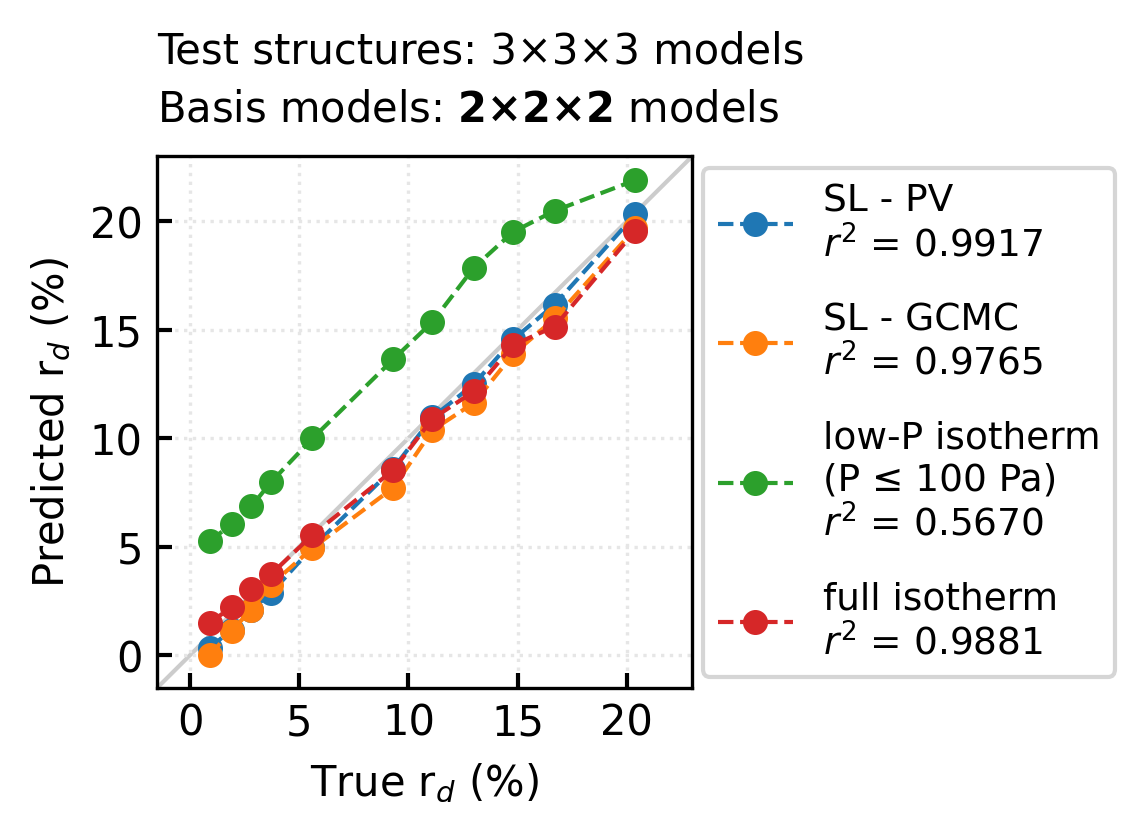

In [29]:
# Overall results.

colors = plt.get_cmap('tab10').colors[:6]
fig,ax = plt.subplots(1,1,figsize=(2.3,2.3),facecolor='None',dpi=300)
ms = 10
lw = 1
ls = '--'
alpha = 1

plt.plot(d_r_all_df['d_r_true'],d_r_all_df['SL_VF'],marker='.',markersize=ms,lw=lw,ls=ls,alpha=alpha,
            color=colors[0],label='SL - PV'
            +'\n$r^{2}$ = '+format(r2_score(d_r_all_df['d_r_true'],d_r_all_df['SL_VF']),'.4f')
           )
plt.plot(d_r_all_df['d_r_true'],d_r_all_df['SL_GCMC'],marker='.',markersize=ms,lw=lw,ls=ls,alpha=alpha,
            color=colors[1],label='SL - GCMC'
            +'\n$r^{2}$ = '+format(r2_score(d_r_all_df['d_r_true'],d_r_all_df['SL_GCMC']),'.4f')
           )
plt.plot(d_r_all_df['d_r_true'],d_r_all_df['N2_iso_set_rmse'],marker='.',markersize=ms,lw=lw,ls=ls,alpha=alpha,
            color=colors[2],label='low-P isotherm\n(P ≤ 100 Pa)'
            +'\n$r^{2}$ = '+format(r2_score(d_r_all_df['d_r_true'],d_r_all_df['N2_iso_set_rmse']),'.4f')
           )
# for i in [0,7,10]:
#     plt.plot(d_r_all_df['d_r_true'][i],d_r_all_df['N2_iso_set_rmse'][i],marker='.',markersize=ms,
#              lw=lw,ls=ls,mfc=colors[2],mec='k',mew=1.3
#            )
# plt.plot(d_r_all_df['d_r_true'],d_r_all_df['N2_iso_set_mae'],marker='.',markersize=ms,lw=lw,ls=ls,
#             label='P ≤ 100 Pa, MAE'
#             +'\n$r^{2}$ = '+format(r2_score(d_r_all_df['d_r_true'],d_r_all_df['N2_iso_set_mae']),'.4f')
#            )
plt.plot(d_r_all_df['d_r_true'],d_r_all_df['N2_iso_full_rmse'],marker='.',markersize=ms,lw=lw,ls=ls,
            color=colors[3],label='full isotherm'
            +'\n$r^{2}$ = '+format(r2_score(d_r_all_df['d_r_true'],d_r_all_df['N2_iso_full_rmse']),'.4f')
           )
# for i in [0,7,10]:
#     plt.plot(d_r_all_df['d_r_true'][i],d_r_all_df['N2_iso_full_rmse'][i],marker='.',markersize=ms,
#              lw=lw,ls=ls,mfc=colors[3],mec='k',mew=1.3
#            )

# plt.plot(d_r_all_df['d_r_true'],d_r_all_df['N2_iso_full_mae'],marker='.',markersize=ms,lw=lw,ls=ls,
#             label='full isotherm, MAE'
#             +'\n$r^{2}$ = '+ format(r2_score(d_r_all_df['d_r_true'],d_r_all_df['N2_iso_full_mae']),'.4f')
#            )

plt.text(-0.,1.16,'Test structures: 3×3×3 models',fontsize=10,ha='left',va='bottom',
         c='k', transform=ax.transAxes)
plt.text(-0.,1.05,r'Basis models: $\mathbf{2×2×2}$ models',fontsize=10,
         ha='left',va='bottom', c='k', transform=ax.transAxes)
plt.plot([-10,100],[-10,100],'-',c='0.8',zorder=1,lw=1)
plt.xlabel('True r$_{d}$ (%)')
plt.ylim(-1.5,23)
plt.xlim(-1.5,23)
plt.xticks(np.arange(0,21,5))
plt.yticks(np.arange(0,21,5))
plt.tick_params(axis='both', which='both', direction='in', labelsize=10,width=1)
plt.ylabel('Predicted r$_{d}$ (%)')
plt.grid(c='0.9',ls=':',lw=0.8,zorder=0)
plt.legend(loc=[1.02,0.02],fontsize=9,labelspacing=1)
# plt.legend(loc='upper left',fontsize=9)
plt.show()

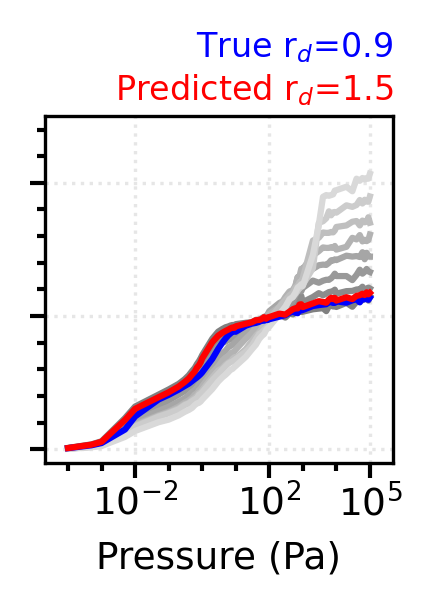

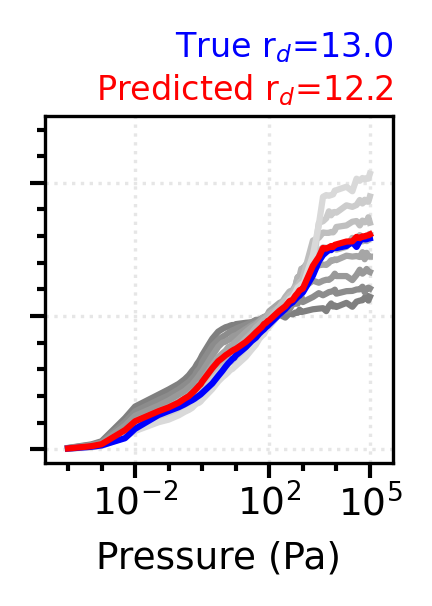

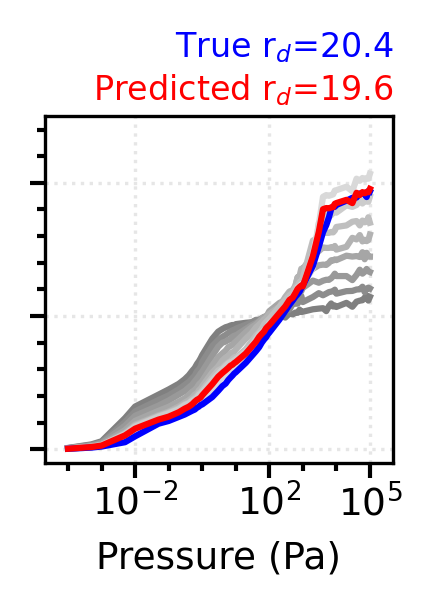

In [17]:
# Isotherms fitting results.

metrics = 'N2_iso_full_rmse'
target = '_'.join(metrics.split('_')[:-1])
lw=1.5
# for f in d_r_all.keys():
for f in ['3_1_009','3_14_130','3_22_204'][:]:
# for f in ['3_10_093']:
    data_f = d_r_all[f]
    fig,ax = plt.subplots(1,1,figsize=(1.5,1.5),facecolor='None',dpi=300)
    d_r_X = data_f[f'{metrics}_X']
    d_r_pred = data_f[f'{metrics}']
    plt.plot(iso_gL['Pressure'],iso_gL[f'{f}_q'],label='test structure\n(3×3×3 model)',c='b',lw=lw,zorder=3)
    master_iso = np.zeros(np.shape(basis_prop['N2_iso_full'][0])[0])
    # X_nor=[i_dis/sum(res.x) for i_dis in d_r_X]
    X_nor=d_r_X
    for i_x in range(len(X_nor)):
        master_iso += basis_prop['N2_iso_full'][list(basis_prop[target].keys())[i_x]]*X_nor[i_x]
    for i_s,s in enumerate(list_2):
        color = format(0.5+(0.05*i_s),'.2f')
        if i_s == 0: plt.plot(iso_gL['Pressure'],iso_gL[f'{s}_q'],
                              label='basis models\n($\\mathbf{2×2×2}$ models)',
                              c=color,lw=lw,zorder=2)
        else: plt.plot(iso_gL['Pressure'],iso_gL[f'{s}_q'],c=color, lw=lw,zorder=2)
    
    plt.plot(iso_gL['Pressure'],master_iso,c='r',label='master\nmodel',lw=lw,zorder=4)
    iso_master_df = pd.DataFrame({'P_rela':iso_gL['Pressure']/1e5, 'q':master_iso*22.4})
    with open(f'for_saieus/master/2_{f}_{metrics}.txt', 'w', newline='\r\n') as file:
        iso_master_df.to_csv(file, sep=' ', header=None, index=False)
    d_r_true = data_f['defect_r']
    ax.text(1,1.15,
            # 'r$_{d,true}$='+
            'True r$_{d}$='+
            format(d_r_true,'.1f'),c='b',fontsize=8,
           ha='right',va='bottom',transform=ax.transAxes)
    ax.text(1,1.025,
            # 'r$_{d,pred}$='+
            'Predicted r$_{d}$='+
            format(d_r_pred,'.1f'),c='r',fontsize=8,
           ha='right',va='bottom',transform=ax.transAxes)
    plt.semilogx()
    
    plt.xlabel('Pressure (Pa)',fontsize=9)
    plt.xlim(0.2e-4,5e5)
    plt.ylim(-1,25)
    # plt.ylabel('N$_{2}$ uptake (mmol/g)',fontsize=9)
    # plt.legend(loc=[0,1.5],frameon=True,fontsize=8,ncol=3,
    #            handlelength=2,labelspacing=0.8,columnspacing=1.5)
    
    plt.yticks([0,10,20])
    plt.yticks([0,10,20],['','','',])
    ax.minorticks_on()
    # ax.xaxis.set_minor_locator(plt.MultipleLocator(10))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=[10], numticks=100))
    ax.xaxis.set_minor_formatter(NullFormatter())
    plt.xticks([1e-2,1e2,1e5])
    plt.tick_params(axis='both', which='both', direction='out', labelsize=9,width=1,pad=1.5)
    plt.grid(which='major',c='0.9',ls=':',lw=0.8,zorder=0)
    # plt.grid(axis='x',which='minor',c='0.9',ls=':',lw=0.8,zorder=0)
    plt.show()